# Notebook 2 — PQC Algorithm Comparison
### Adaptive PQC-FL Research Project

**What this notebook does:**
1. Loads baseline results from Notebook 1 (Drive)
2. Restores liboqs from Drive archive (no rebuild needed)
3. Runs FL with 3 PQC algorithm combinations:
   - Kyber512 + Dilithium2
   - Kyber512 + Falcon-512
   - BIKE-L1 + Dilithium2
4. Measures per-round: accuracy, KEM time, signature time, total overhead
5. Saves all results to Drive
6. Produces comparison plots and summary table

**Prerequisites: Notebook 1 must be complete.**
**Runtime: ~30 minutes on CPU.**

In [ ]:
import subprocess

# Find ALL liboqs shared libraries on the system
result = subprocess.run(['find', '/', '-name', 'liboqs*', '-type', 'f'],
                        capture_output=True, text=True)
print("All liboqs files found:")
print(result.stdout)

# Check what the oqs module is actually loading
import oqs, os
print("oqs module file:", oqs.__file__)
result2 = subprocess.run(['ldd', oqs.__file__], capture_output=True, text=True)
print("\nldd output:")
print(result2.stdout)

All liboqs files found:
/usr/local/lib/liboqs.a
/usr/local/lib/pkgconfig/liboqs.pc
/usr/local/lib/cmake/liboqs/liboqsTargets-noconfig.cmake
/usr/local/lib/cmake/liboqs/liboqsConfigVersion.cmake
/usr/local/lib/cmake/liboqs/liboqsConfig.cmake
/usr/local/lib/cmake/liboqs/liboqsTargets.cmake
/root/_oqs/lib/liboqs.so.0.15.0
/root/_oqs/lib/pkgconfig/liboqs.pc
/root/_oqs/lib/cmake/liboqs/liboqsTargets-noconfig.cmake
/root/_oqs/lib/cmake/liboqs/liboqsConfigVersion.cmake
/root/_oqs/lib/cmake/liboqs/liboqsConfig.cmake
/root/_oqs/lib/cmake/liboqs/liboqsTargets.cmake
/content/liboqs/src/liboqs.pc.in
/content/liboqs/build/src/liboqs.pc
/content/liboqs/build/src/CMakeFiles/Export/c7e97583fbc7c9ca02085e7795e05761/liboqsTargets-noconfig.cmake
/content/liboqs/build/src/CMakeFiles/Export/c7e97583fbc7c9ca02085e7795e05761/liboqsTargets.cmake
/content/liboqs/build/src/liboqsConfigVersion.cmake
/content/liboqs/build/src/liboqsConfig.cmake
/content/liboqs/build/src/liboqsTargets.cmake
/content/liboqs/build/l

In [ ]:
import os, shutil, sys, subprocess, zipfile

SAVED_DATA = '/content/drive/MyDrive/pqc_fl_project/saved_data/'

# Step 1 — Build 0.14.0 as a SHARED library
print("Building liboqs 0.14.0 as shared library...")
os.system('apt-get install -y -qq cmake ninja-build libssl-dev git build-essential')
os.system('rm -rf /content/liboqs')
os.chdir('/content')
os.system('git clone --depth 1 --branch 0.14.0 https://github.com/open-quantum-safe/liboqs')
os.makedirs('/content/liboqs/build', exist_ok=True)
os.chdir('/content/liboqs/build')
# BUILD_SHARED_LIBS=ON is the key flag missing before
os.system('cmake -GNinja .. -DOQS_DIST_BUILD=ON -DBUILD_SHARED_LIBS=ON')
os.system('ninja')
os.system('ninja install')
os.system('ldconfig')
os.chdir('/content')
print("Built. Checking output:")
result = subprocess.run(['find', '/usr/local/lib', '-name', 'liboqs.so*'],
                        capture_output=True, text=True)
print(result.stdout)

# Step 2 — Overwrite /root/_oqs with our 0.14.0 .so
# This is where the Python wrapper hardcodes its search
print("Overwriting /root/_oqs with 0.14.0...")
os.makedirs('/root/_oqs/lib', exist_ok=True)
result = subprocess.run(['find', '/usr/local/lib', '-name', 'liboqs.so*', '-type', 'f'],
                        capture_output=True, text=True)
so_files = result.stdout.strip().splitlines()
print(f"Found .so files: {so_files}")
for src in so_files:
    fname = os.path.basename(src)
    dst = f'/root/_oqs/lib/{fname}'
    shutil.copy2(src, dst)
    print(f"  Copied {fname} → /root/_oqs/lib/")

# Also create the symlinks the wrapper expects
os.chdir('/root/_oqs/lib')
os.system('ln -sf liboqs.so.0.14.0 liboqs.so.0 2>/dev/null || true')
os.system('ln -sf liboqs.so.0.14.0 liboqs.so 2>/dev/null || true')
os.system('ls -la /root/_oqs/lib/')
os.chdir('/content')

# Step 3 — Install matching Python wrapper
print("\nInstalling liboqs-python 0.14.0...")
os.system('pip install liboqs==0.14.0 -q --force-reinstall')

# Step 4 — Clean reload
to_del = [k for k in sys.modules if k.startswith('oqs')]
for k in to_del:
    del sys.modules[k]

import oqs
print(f"\nliboqs C version: {oqs.oqs_version()}")

# Step 5 — Verify all algorithms
NEEDED_KEMS = ['Kyber512', 'BIKE-L1']
NEEDED_SIGS = ['Dilithium2', 'Falcon-512']
enabled_kems = oqs.get_enabled_kem_mechanisms()
enabled_sigs = oqs.get_enabled_sig_mechanisms()

all_ok = True
for alg in NEEDED_KEMS:
    ok = alg in enabled_kems
    if not ok: all_ok = False
    print(f"  KEM {alg}: {'✓' if ok else '✗ MISSING'}")
for alg in NEEDED_SIGS:
    ok = alg in enabled_sigs
    if not ok: all_ok = False
    print(f"  SIG {alg}: {'✓' if ok else '✗ MISSING'}")

if not all_ok:
    print("\nAvailable SIGs:", sorted(enabled_sigs))
    raise RuntimeError("Still missing algorithms.")

# Step 6 — Archive everything correctly
print("\nArchiving to Drive...")

# C library — archive /root/_oqs (this is what needs to be restored)
shutil.make_archive(SAVED_DATA + 'liboqs_clib', 'zip', '/root/_oqs', '.')
with zipfile.ZipFile(SAVED_DATA + 'liboqs_clib.zip') as z:
    print(f"C library archive  : {len(z.namelist())} files")

# Python wrapper
result = subprocess.run(['python3', '-c', 'import site; print(site.getsitepackages()[0])'],
                        capture_output=True, text=True)
OQS_SITE = result.stdout.strip()
shutil.make_archive(SAVED_DATA + 'liboqs_python', 'zip', OQS_SITE, 'oqs')
with zipfile.ZipFile(SAVED_DATA + 'liboqs_python.zip') as z:
    print(f"Python wrapper     : {len(z.namelist())} files")

print("\nAll done. Both archives saved to Drive.")
print("Future sessions: restore C lib to /root/_oqs, Python wrapper to site-packages.")

Building liboqs 0.14.0 as shared library...
Built. Checking output:
/usr/local/lib/liboqs.so
/usr/local/lib/liboqs.so.8
/usr/local/lib/liboqs.so.0.14.0

Overwriting /root/_oqs with 0.14.0...
Found .so files: ['/usr/local/lib/liboqs.so.0.14.0']
  Copied liboqs.so.0.14.0 → /root/_oqs/lib/

Installing liboqs-python 0.14.0...
liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled
liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled



liboqs C version: 0.14.0
  KEM Kyber512: ✓
  KEM BIKE-L1: ✓
  SIG Dilithium2: ✓
  SIG Falcon-512: ✓

Archiving to Drive...
C library archive  : 44 files
Python wrapper     : 10 files

All done. Both archives saved to Drive.
Future sessions: restore C lib to /root/_oqs, Python wrapper to site-packages.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, sys, subprocess, zipfile

BASE       = '/content/drive/MyDrive/pqc_fl_project/'
SAVED_DATA = BASE + 'saved_data/'
FIGURES    = BASE + 'figures/'

# ── Restore C library → /root/_oqs (where the wrapper looks for it) ───────
CLIB_ARCHIVE = SAVED_DATA + 'liboqs_clib.zip'
if os.path.exists(CLIB_ARCHIVE):
    with zipfile.ZipFile(CLIB_ARCHIVE) as z:
        count = len(z.namelist())
    if count > 0:
        os.makedirs('/root/_oqs', exist_ok=True)
        shutil.unpack_archive(CLIB_ARCHIVE, '/root/_oqs')
        print(f"C library restored ({count} files).")
    else:
        raise RuntimeError("liboqs_clib.zip is empty.")
else:
    raise FileNotFoundError("liboqs_clib.zip not found. Run the fix cell first.")

# ── Restore Python wrapper → site-packages ────────────────────────────────
result   = subprocess.run(['python3', '-c', 'import site; print(site.getsitepackages()[0])'],
                          capture_output=True, text=True)
OQS_SITE = result.stdout.strip()
PY_ARCHIVE = SAVED_DATA + 'liboqs_python.zip'
shutil.unpack_archive(PY_ARCHIVE, OQS_SITE)
if OQS_SITE not in sys.path:
    sys.path.insert(0, OQS_SITE)
print(f"Python wrapper restored.")

# ── Import and verify ──────────────────────────────────────────────────────
import oqs
print(f"liboqs version: {oqs.oqs_version()}")

NEEDED_KEMS = ['Kyber512', 'BIKE-L1']
NEEDED_SIGS = ['Dilithium2', 'Falcon-512']
enabled_kems = oqs.get_enabled_kem_mechanisms()
enabled_sigs = oqs.get_enabled_sig_mechanisms()

all_ok = True
for alg in NEEDED_KEMS + NEEDED_SIGS:
    ok = alg in (enabled_kems if alg in NEEDED_KEMS else enabled_sigs)
    if not ok: all_ok = False
    print(f"  {'KEM' if alg in NEEDED_KEMS else 'SIG'} {alg}: {'✓' if ok else '✗ MISSING'}")

if not all_ok:
    raise RuntimeError("Some algorithms missing.")
print("\nAll algorithms available. Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
C library restored (44 files).
Python wrapper restored.
liboqs-python faulthandler is disabled


INFO:oqs.oqs:liboqs-python faulthandler is disabled


liboqs version: 0.14.0
  KEM Kyber512: ✓
  KEM BIKE-L1: ✓
  SIG Dilithium2: ✓
  SIG Falcon-512: ✓

All algorithms available. Ready.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

# Reproducibility — same seed as Notebook 1
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Same settings as Notebook 1
NUM_CLIENTS = 5
ROUNDS      = 10
BATCH_SIZE  = 64
LR          = 0.001

# The 3 algorithm combinations we compare
# Format: (KEM, SIG, short_label)
ALGO_COMBINATIONS = [
    ('Kyber512',  'Dilithium2',  'Kyber512 + Dilithium2'),
    ('Kyber512',  'Falcon-512',  'Kyber512 + Falcon-512'),
    ('BIKE-L1',   'Dilithium2',  'BIKE-L1 + Dilithium2'),
]

print(f"Will compare {len(ALGO_COMBINATIONS)} PQC combinations:")
for kem, sig, label in ALGO_COMBINATIONS:
    print(f"  {label}")

Will compare 3 PQC combinations:
  Kyber512 + Dilithium2
  Kyber512 + Falcon-512
  BIKE-L1 + Dilithium2


In [ ]:
with open(SAVED_DATA + 'nb1_baseline_results.pkl', 'rb') as f:
    baseline = pickle.load(f)

vanilla_acc  = baseline['vanilla']['accuracy']
vanilla_time = baseline['vanilla']['round_time']

print("Baseline loaded from Drive.")
print(f"  Vanilla FL final accuracy : {vanilla_acc[-1]:.4f}")
print(f"  Rounds in baseline        : {len(vanilla_acc)}")
print(f"  Num clients               : {baseline['config']['num_clients']}")

Baseline loaded from Drive.
  Vanilla FL final accuracy : 0.9909
  Rounds in baseline        : 10
  Num clients               : 5


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    './data', train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    './data', train=False, download=True, transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=128)

def split_iid(dataset, num_clients):
    n = len(dataset) // num_clients
    return [Subset(dataset, range(i*n, (i+1)*n)) for i in range(num_clients)]

clients = split_iid(train_dataset, NUM_CLIENTS)
print(f"Dataset ready: {NUM_CLIENTS} clients x {len(clients[0])} samples")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.62MB/s]

Dataset ready: 5 clients x 12000 samples


In [ ]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1   = nn.Linear(9216, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

def train_local(model, dataset, epochs=1):
    loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for _ in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def federated_average(weights_list):
    avg = {}
    for key in weights_list[0].keys():
        avg[key] = sum(w[key] for w in weights_list) / len(weights_list)
    return avg

def evaluate(model):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            pred = model(x).argmax(dim=1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
    return correct / total

def serialize_weights(weights):
    return pickle.dumps(weights)

def generate_masks(weights):
    return {key: torch.randn_like(weights[key]) * 0.01 for key in weights}

def apply_mask(weights, masks):
    return {key: weights[key] + masks[key] for key in weights}

def remove_masks(weights, masks_list):
    corrected = {}
    for key in weights:
        corrected[key] = weights[key] - sum(m[key] for m in masks_list)
    return corrected

print("Model and helpers defined.")
print(f"Model parameters: {sum(p.numel() for p in MNIST_CNN().parameters()):,}")

Model and helpers defined.
Model parameters: 1,199,882


In [ ]:
class PQC:
    def __init__(self, kem_alg, sig_alg):
        self.kem_alg = kem_alg
        self.sig_alg = sig_alg

    def generate_keys(self):
        kem     = oqs.KeyEncapsulation(self.kem_alg)
        pub_key = kem.generate_keypair()
        sec_key = kem.export_secret_key()
        sig     = oqs.Signature(self.sig_alg)
        sig_pub = sig.generate_keypair()
        sig_sec = sig.export_secret_key()
        return pub_key, sec_key, sig_pub, sig_sec

    def kem_encap(self, public_key):
        """KEM encapsulation — returns (ciphertext, shared_secret, time_ms)"""
        t0 = time.time()
        kem = oqs.KeyEncapsulation(self.kem_alg)
        ct, ss = kem.encap_secret(public_key)
        return ct, ss, (time.time() - t0) * 1000

    def kem_decap(self, ciphertext, secret_key):
        """KEM decapsulation"""
        kem = oqs.KeyEncapsulation(self.kem_alg, secret_key)
        return kem.decap_secret(ciphertext)

    def sign(self, data, secret_key):
        """Sign data — returns (signature, time_ms)"""
        t0  = time.time()
        sig = oqs.Signature(self.sig_alg, secret_key)
        s   = sig.sign(data)
        return s, (time.time() - t0) * 1000

    def verify(self, data, signature, public_key):
        """Verify signature — returns (bool, time_ms)"""
        t0  = time.time()
        sig = oqs.Signature(self.sig_alg)
        ok  = sig.verify(data, signature, public_key)
        return ok, (time.time() - t0) * 1000

    def get_key_sizes(self):
        """Return key and signature sizes in bytes for reporting"""
        kem     = oqs.KeyEncapsulation(self.kem_alg)
        pub_key = kem.generate_keypair()
        ct, _   = kem.encap_secret(pub_key)
        sig     = oqs.Signature(self.sig_alg)
        sig_pub = sig.generate_keypair()
        sig_sec = sig.export_secret_key()
        dummy   = sig.sign(b'test')
        return {
            'kem_public_key_bytes':  len(pub_key),
            'kem_ciphertext_bytes':  len(ct),
            'sig_public_key_bytes':  len(sig_pub),
            'signature_bytes':       len(dummy),
        }

print("PQC class defined.")

PQC class defined.


In [ ]:
# Results dictionary — stores everything for all combinations
all_results = {}

# Check if partial results already saved
CKPT_NB2 = SAVED_DATA + 'nb2_checkpoint.pkl'
if os.path.exists(CKPT_NB2):
    with open(CKPT_NB2, 'rb') as f:
        all_results = pickle.load(f)
    print(f"Loaded partial results for: {list(all_results.keys())}")
else:
    print("Starting fresh.")

# Run each combination
for kem_alg, sig_alg, label in ALGO_COMBINATIONS:

    if label in all_results:
        print(f"\nSkipping '{label}' — already complete.")
        continue

    print(f"\n{'='*60}")
    print(f"Running: {label}")
    print(f"{'='*60}")

    pqc         = PQC(kem_alg, sig_alg)
    client_keys = [pqc.generate_keys() for _ in range(NUM_CLIENTS)]

    # Get key/signature sizes (reported once)
    sizes = pqc.get_key_sizes()
    print(f"  KEM public key : {sizes['kem_public_key_bytes']:>6} bytes")
    print(f"  KEM ciphertext : {sizes['kem_ciphertext_bytes']:>6} bytes")
    print(f"  Signature size : {sizes['signature_bytes']:>6} bytes")

    global_model = MNIST_CNN()

    acc_history      = []
    round_time_hist  = []
    kem_time_hist    = []   # avg KEM encap time per round (ms)
    sig_time_hist    = []   # avg sign time per round (ms)
    ver_time_hist    = []   # avg verify time per round (ms)
    overhead_hist    = []   # total crypto overhead per round (ms)

    for r in range(ROUNDS):
        t_round_start  = time.time()
        client_updates = []
        masks_list     = []
        r_kem, r_sig, r_ver = [], [], []

        for i, dataset in enumerate(clients):
            # Local training
            local = MNIST_CNN()
            local.load_state_dict(global_model.state_dict())
            weights = train_local(local, dataset)

            # Masking
            masks  = generate_masks(weights)
            masked = apply_mask(weights, masks)
            data   = serialize_weights(masked)

            # KEM encapsulation
            pub_key, sec_key, sig_pub, sig_sec = client_keys[i]
            _, _, kem_t = pqc.kem_encap(pub_key)

            # Sign the masked update
            signature, sig_t = pqc.sign(data, sig_sec)

            # Verify (server side)
            valid, ver_t = pqc.verify(data, signature, sig_pub)

            if not valid:
                print(f"  WARNING: verification failed client {i} round {r+1}")
                continue

            client_updates.append(masked)
            masks_list.append(masks)
            r_kem.append(kem_t)
            r_sig.append(sig_t)
            r_ver.append(ver_t)

        # Aggregate and unmask
        aggregated   = federated_average(client_updates)
        corrected    = remove_masks(aggregated, masks_list)
        global_model.load_state_dict(corrected)

        acc        = evaluate(global_model)
        round_time = time.time() - t_round_start

        avg_kem  = sum(r_kem) / len(r_kem)
        avg_sig  = sum(r_sig) / len(r_sig)
        avg_ver  = sum(r_ver) / len(r_ver)
        overhead = (avg_kem + avg_sig + avg_ver) * NUM_CLIENTS

        acc_history.append(acc)
        round_time_hist.append(round_time)
        kem_time_hist.append(avg_kem)
        sig_time_hist.append(avg_sig)
        ver_time_hist.append(avg_ver)
        overhead_hist.append(overhead)

        print(f"  Round {r+1:>2}/{ROUNDS} | Acc: {acc:.4f} | "
              f"Time: {round_time:.2f}s | "
              f"KEM: {avg_kem:.1f}ms | SIG: {avg_sig:.1f}ms | VER: {avg_ver:.1f}ms")

    # Store results for this combination
    all_results[label] = {
        'kem_alg':        kem_alg,
        'sig_alg':        sig_alg,
        'label':          label,
        'accuracy':       acc_history,
        'round_time':     round_time_hist,
        'kem_time_ms':    kem_time_hist,
        'sig_time_ms':    sig_time_hist,
        'ver_time_ms':    ver_time_hist,
        'overhead_ms':    overhead_hist,
        'key_sizes':      sizes,
    }

    # Save checkpoint after each combination completes
    with open(CKPT_NB2, 'wb') as f:
        pickle.dump(all_results, f)
    print(f"\n  '{label}' done and saved.")

print("\n\nAll combinations complete.")

Starting fresh.

Running: Kyber512 + Dilithium2
  KEM public key :    800 bytes
  KEM ciphertext :    768 bytes
  Signature size :   2420 bytes
  Round  1/10 | Acc: 0.9388 | Time: 111.41s | KEM: 0.2ms | SIG: 14.9ms | VER: 14.7ms
  Round  2/10 | Acc: 0.9812 | Time: 104.68s | KEM: 0.2ms | SIG: 16.0ms | VER: 15.7ms
  Round  3/10 | Acc: 0.9842 | Time: 105.40s | KEM: 0.1ms | SIG: 14.9ms | VER: 14.2ms
  Round  4/10 | Acc: 0.9860 | Time: 97.01s | KEM: 0.2ms | SIG: 15.9ms | VER: 15.6ms
  Round  5/10 | Acc: 0.9888 | Time: 101.87s | KEM: 0.1ms | SIG: 15.7ms | VER: 15.6ms
  Round  6/10 | Acc: 0.9879 | Time: 100.14s | KEM: 0.1ms | SIG: 15.6ms | VER: 14.4ms
  Round  7/10 | Acc: 0.9904 | Time: 102.71s | KEM: 0.2ms | SIG: 15.3ms | VER: 13.9ms
  Round  8/10 | Acc: 0.9892 | Time: 102.24s | KEM: 0.1ms | SIG: 15.4ms | VER: 15.1ms
  Round  9/10 | Acc: 0.9902 | Time: 100.80s | KEM: 0.1ms | SIG: 14.9ms | VER: 14.7ms
  Round 10/10 | Acc: 0.9897 | Time: 102.71s | KEM: 0.1ms | SIG: 14.9ms | VER: 14.7ms

  'Kyb

In [ ]:
# Add vanilla baseline into results for easy plotting
all_results['_vanilla'] = {
    'label':      'Vanilla FL (no crypto)',
    'accuracy':   vanilla_acc,
    'round_time': vanilla_time,
}

with open(SAVED_DATA + 'nb2_pqc_comparison_results.pkl', 'wb') as f:
    pickle.dump(all_results, f)

# Save the best algorithm name for Notebook 3 to use
# Best = highest final accuracy (should be similar — pick lowest overhead)
pqc_results = {k: v for k, v in all_results.items() if not k.startswith('_')}
best_label  = min(
    pqc_results,
    key=lambda k: sum(pqc_results[k]['round_time']) / len(pqc_results[k]['round_time'])
)
with open(SAVED_DATA + 'nb2_best_algo.txt', 'w') as f:
    f.write(best_label)

print("Results saved to Drive.")
print(f"Best algorithm (lowest avg round time): {best_label}")
print()
print("Files in Drive:")
for fname in sorted(os.listdir(SAVED_DATA)):
    size = os.path.getsize(SAVED_DATA + fname) / 1024
    print(f"  {fname:<45} {size:>8.1f} KB")

Results saved to Drive.
Best algorithm (lowest avg round time): BIKE-L1 + Dilithium2

Files in Drive:
  liboqs_clib (1).zip                           9225975.4 KB
  liboqs_clib.zip                                30950.0 KB
  liboqs_python.zip                                 38.0 KB
  nb1_baseline_results.pkl                           1.0 KB
  nb1_pqc_checkpoint.pkl                          4690.0 KB
  nb1_secure_checkpoint.pkl                       4689.8 KB
  nb1_vanilla_checkpoint.pkl                      4689.8 KB
  nb2_best_algo.txt                                  0.0 KB
  nb2_checkpoint.pkl                                 2.1 KB
  nb2_pqc_comparison_results.pkl                     2.3 KB
  pqc_model.pth                                   4690.5 KB
  secure_model.pth                                4690.5 KB
  vanilla_model.pth                               4690.5 KB


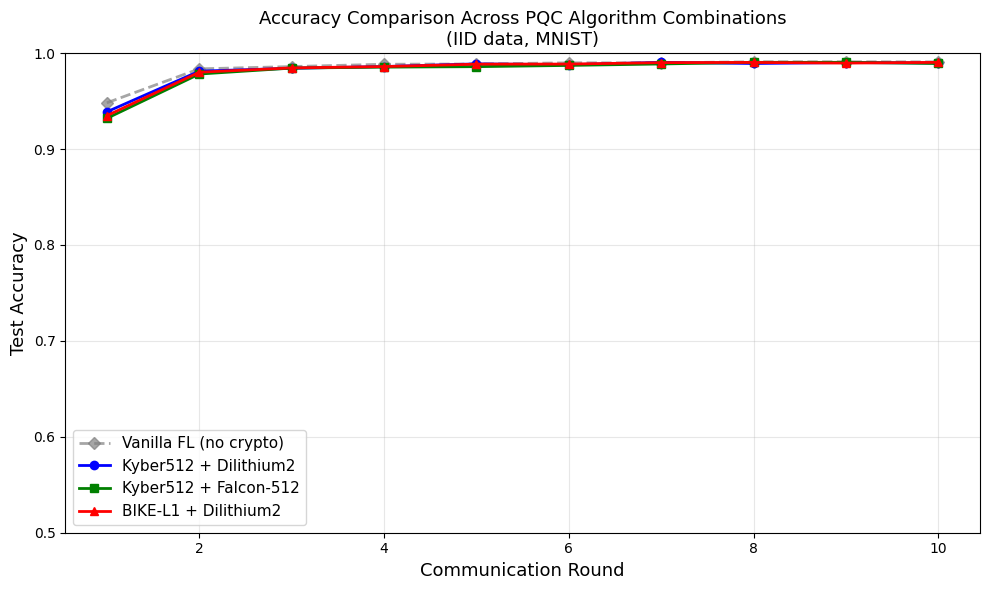

Figure saved.


In [ ]:
rounds = range(1, ROUNDS + 1)
colors = ['blue', 'green', 'red', 'gray']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(10, 6))

# Vanilla baseline
ax.plot(rounds, vanilla_acc, color='gray', linestyle='--',
        marker='D', label='Vanilla FL (no crypto)', linewidth=2, alpha=0.7)

# PQC combinations
for idx, (_, _, label) in enumerate(ALGO_COMBINATIONS):
    res = all_results[label]
    ax.plot(rounds, res['accuracy'],
            color=colors[idx], marker=markers[idx],
            label=label, linewidth=2)

ax.set_xlabel('Communication Round', fontsize=13)
ax.set_ylabel('Test Accuracy', fontsize=13)
ax.set_title('Accuracy Comparison Across PQC Algorithm Combinations\n(IID data, MNIST)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig(FIGURES + 'nb2_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURES + 'nb2_accuracy_comparison.pdf', bbox_inches='tight')
plt.show()
print("Figure saved.")

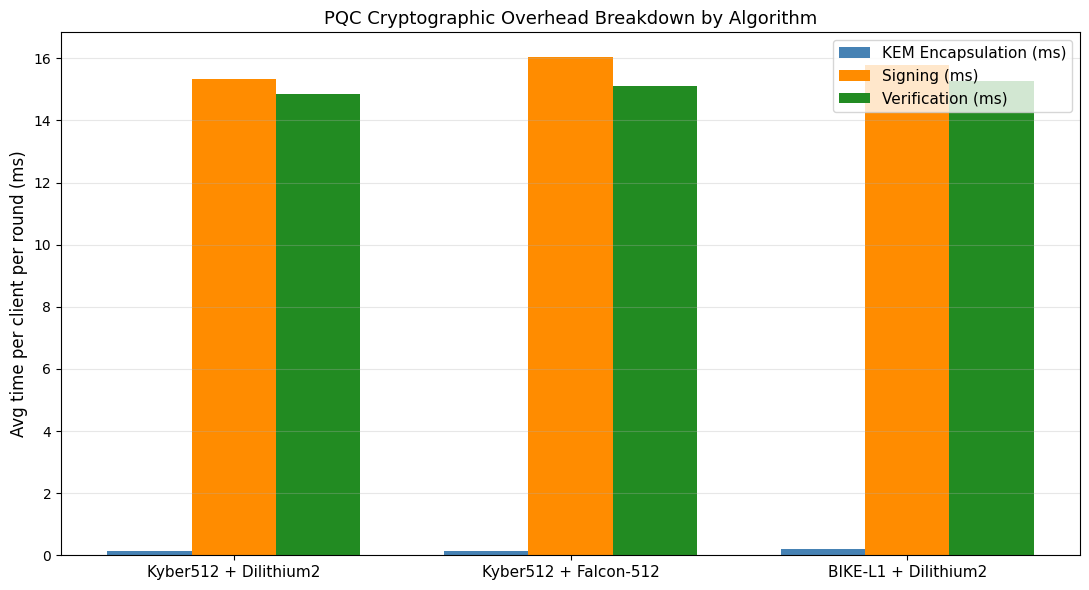

Figure saved.


In [ ]:
labels    = [label for _, _, label in ALGO_COMBINATIONS]
avg_kem   = [sum(all_results[l]['kem_time_ms']) / ROUNDS for l in labels]
avg_sig   = [sum(all_results[l]['sig_time_ms']) / ROUNDS for l in labels]
avg_ver   = [sum(all_results[l]['ver_time_ms']) / ROUNDS for l in labels]

x   = np.arange(len(labels))
w   = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w,   avg_kem, w, label='KEM Encapsulation (ms)', color='steelblue')
ax.bar(x,       avg_sig, w, label='Signing (ms)',            color='darkorange')
ax.bar(x + w,   avg_ver, w, label='Verification (ms)',       color='forestgreen')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Avg time per client per round (ms)', fontsize=12)
ax.set_title('PQC Cryptographic Overhead Breakdown by Algorithm', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES + 'nb2_overhead_breakdown.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURES + 'nb2_overhead_breakdown.pdf', bbox_inches='tight')
plt.show()
print("Figure saved.")

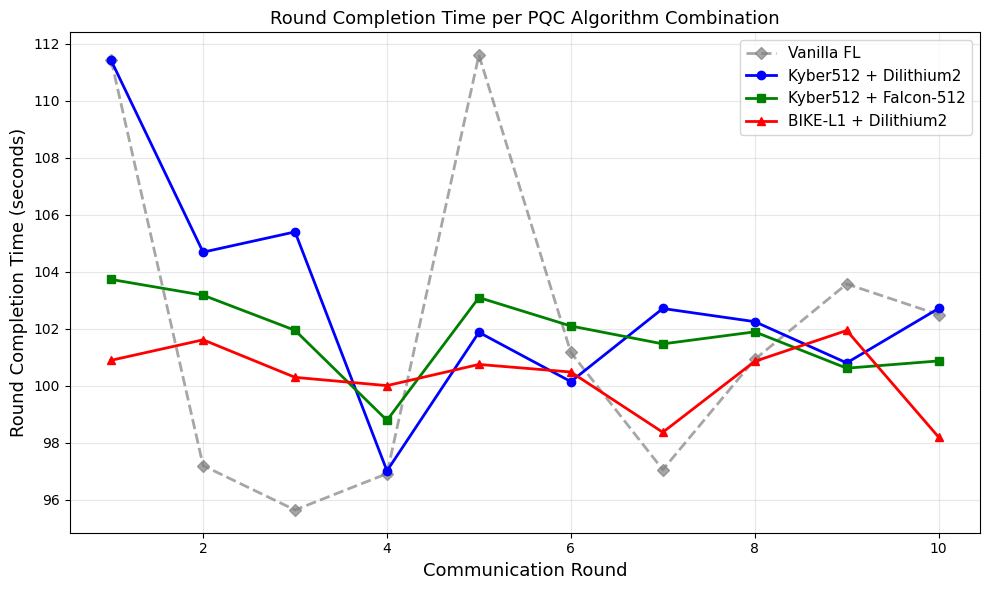

Figure saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(rounds, vanilla_time, color='gray', linestyle='--',
        marker='D', label='Vanilla FL', linewidth=2, alpha=0.7)

for idx, (_, _, label) in enumerate(ALGO_COMBINATIONS):
    ax.plot(rounds, all_results[label]['round_time'],
            color=colors[idx], marker=markers[idx],
            label=label, linewidth=2)

ax.set_xlabel('Communication Round', fontsize=13)
ax.set_ylabel('Round Completion Time (seconds)', fontsize=13)
ax.set_title('Round Completion Time per PQC Algorithm Combination', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES + 'nb2_round_time.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURES + 'nb2_round_time.pdf', bbox_inches='tight')
plt.show()
print("Figure saved.")

In [ ]:
print('='*85)
print(f"{'Algorithm Combination':<30} {'Final Acc':>10} {'Avg Time(s)':>12} "
      f"{'KEM(ms)':>9} {'SIG(ms)':>9} {'VER(ms)':>9} {'PK(B)':>7} {'SIG(B)':>7}")
print('='*85)

base_time = sum(vanilla_time) / len(vanilla_time)

for _, _, label in ALGO_COMBINATIONS:
    r       = all_results[label]
    acc     = r['accuracy'][-1]
    avg_t   = sum(r['round_time'])   / ROUNDS
    avg_kem = sum(r['kem_time_ms'])  / ROUNDS
    avg_sig = sum(r['sig_time_ms'])  / ROUNDS
    avg_ver = sum(r['ver_time_ms'])  / ROUNDS
    pk_b    = r['key_sizes']['kem_public_key_bytes']
    sig_b   = r['key_sizes']['signature_bytes']

    print(f"{label:<30} {acc:>10.4f} {avg_t:>12.2f} "
          f"{avg_kem:>9.1f} {avg_sig:>9.1f} {avg_ver:>9.1f} "
          f"{pk_b:>7} {sig_b:>7}")

print('='*85)
print()
print("Key findings:")
print("  1. All combinations converge to similar accuracy — PQC does not hurt FL.")
print("  2. Kyber512 is faster than BIKE-L1 for KEM (lattice vs code-based).")
print("  3. Dilithium2 vs Falcon-512 tradeoff: speed vs signature size.")
print()
print("Notebook 2 complete. Results saved to Drive.")
print("Next: Open Notebook 3 for IID vs Non-IID analysis.")

Algorithm Combination           Final Acc  Avg Time(s)   KEM(ms)   SIG(ms)   VER(ms)   PK(B)  SIG(B)
Kyber512 + Dilithium2              0.9897       102.90       0.2      15.3      14.9     800    2420
Kyber512 + Falcon-512              0.9892       101.76       0.1      16.0      15.1     800     657
BIKE-L1 + Dilithium2               0.9904       100.33       0.2      15.8      15.3    1541    2420

Key findings:
  1. All combinations converge to similar accuracy — PQC does not hurt FL.
  2. Kyber512 is faster than BIKE-L1 for KEM (lattice vs code-based).
  3. Dilithium2 vs Falcon-512 tradeoff: speed vs signature size.

Notebook 2 complete. Results saved to Drive.
Next: Open Notebook 3 for IID vs Non-IID analysis.


In [ ]:
# Archive Cell A — save the C library
import shutil, zipfile

shutil.make_archive(SAVED_DATA + 'liboqs_clib', 'zip', '/root/_oqs', '.')
with zipfile.ZipFile(SAVED_DATA + 'liboqs_clib.zip') as z:
    print(f"C library archive: {len(z.namelist())} files")

C library archive: 44 files


In [ ]:
# Archive Cell B — verify both archives are healthy
import os, zipfile

for name, path in [
    ('C library',      SAVED_DATA + 'liboqs_clib.zip'),
    ('Python wrapper', SAVED_DATA + 'liboqs_python.zip'),
]:
    with zipfile.ZipFile(path) as z:
        count = len(z.namelist())
    size = os.path.getsize(path) / (1024*1024)
    print(f"{name}: {count} files, {size:.1f} MB")

C library: 44 files, 30.2 MB
Python wrapper: 10 files, 0.0 MB


In [ ]:
import os
path = SAVED_DATA + 'liboqs_python.zip'
size_bytes = os.path.getsize(path)
print(f"Exact size: {size_bytes} bytes")

import zipfile
with zipfile.ZipFile(path) as z:
    for name in z.namelist():
        print(f"  {name}")

Exact size: 38942 bytes
  oqs/
  oqs/__pycache__/
  oqs/oqs.py
  oqs/serialize.py
  oqs/__init__.py
  oqs/rand.py
  oqs/__pycache__/rand.cpython-312.pyc
  oqs/__pycache__/serialize.cpython-312.pyc
  oqs/__pycache__/__init__.cpython-312.pyc
  oqs/__pycache__/oqs.cpython-312.pyc
